In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
from fft_sup_imports import * 
import pandas as pd
%matplotlib inline
update_rc_params('paper')


In [2]:
def SdH_amplitude(T, mstar, B):
    chi = 2 * np.pi**2 * k_B * T * mstar * m_e / (hbar * e * B)
    return chi / np.sinh(chi)

def Beff(Blo, Bhi):
    # Harmonic mean of Blo and Bhi
    return 2 / (1/Blo + 1/Bhi)



418.10447105788427
419.3840918163673
418.41528942115775
418.7854091816367
535.7555489021955
419.1010578842315
417.564510978044
418.62682634730544


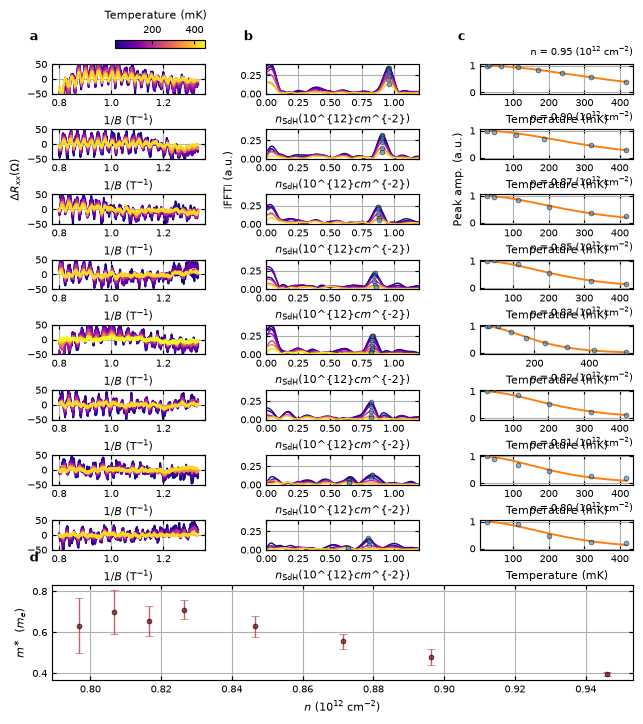

In [3]:
import scipy.optimize
label_spacer = 0.03
peak_color = '#377EB8'
def do_mass_fit(fig, axes, files, n_nom, D_nom, target_f=1, bg_subtract=None, plot_cbar=False, plot_xlabels=True, plot_ylabels=False, contact_pair =2 ):
    Vtg, Vbg = calculate_gate_voltages(n_nom, D_nom, dtg=rmg19['experimental']['dtg'], dbg=rmg19['experimental']['dbg'])
    n, D = calculate_n_D(Vtg, Vbg, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])

    popts, pcovs = [], []
    ffts = []
    freqs = []
    temps = []
    temp_cmap = plt.cm.plasma 
    temp_norm = plt.Normalize(vmin=25, vmax=450)
    sdh_peaks = []
    cb_width = 0.12
    y_offset = 1.5
    ax = axes[0]
    for file in files:
        # load in the new data
        data = sl.pload(file_path, file)
        mc_0 = data['measurement_config']
        md = sl.load_meta(file_path, file)
        xs = data['xs']
        I = data['sr830_4_X']
        Vxx = data[f'sr830_{contact_pair}_X']
        zs = Vxx/I

        
        invB_range = np.max(1/xs) - np.min(1/xs)
        num_invB_pts = int(np.ceil(invB_range / np.min(np.abs(np.diff(1/xs)))))
        temp = np.nanmean(data['T']) * 1e3

        # Get the fft
        padding = 8
        if bg_subtract == 'linear':
            zs_detrended, bg = detrend_poly(xs, zs, degree=1)
        elif bg_subtract == 'butter':
            zs_detrended, bg = detrend_butterworth(xs, zs, cutoff=1, order=4)
        elif bg_subtract == None:
            zs_detrended = zs - np.mean(zs)
        else:
            raise ValueError("Invalid Background Subtraction Scheme")
        
        interp_invB, interp_zs = interp_rxx(xs, zs_detrended, nx=num_invB_pts)
        # rxx, bg = detrend_butterworth(interp_invB, interp_zs, cutoff = 2, order=4)
        # rxx, bg = detrend_butterworth(interp_invB, interp_zs, cutoff = 3, order=3)
        # rxx = interp_zs - np.mean(interp_zs)
        rxx = interp_zs 
        
        fft, freq_b = make_vec_fft(interp_invB, rxx, n=n, padding=padding, return_complex=True, normalize=False)
        ffts.append(fft[:len(freq_b)//2] / len(freq_b) ) 
        freqs.append(freq_b[:len(freq_b)//2])
        temps.append(temp)
        
        
        plot = ax.plot(interp_invB, interp_zs, color = temp_cmap(temp_norm(temp)))
        # plot = ax.plot(interp_invB, bg, color = temp_cmap_general(temp_norm_general(temp)), alpha = 0.5)
        if plot_ylabels:
            ax.set_ylabel(r"$\Delta R_{xx} (\Omega)$", y=y_offset)
        if plot_xlabels:
            ax.set_xlabel(r"$1/B$ (T$^{-1}$)")
        ax.set_ylim(-50, 50)
        # # FOR TESTING: can use stdev and should get similar results as signal is mostly one freq.

    # if plot_cbar:
    #     sm = plt.cm.ScalarMappable(cmap=temp_cmap, norm=temp_norm)
    #     sm.set_array([])
    #     pos = ax.get_position()
    #     cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
    #     cb = plt.colorbar(sm, ax=ax, cax=cax, orientation='horizontal', shrink=0.3, pad=0.01, aspect=5)
    if plot_cbar:
        sm = plt.cm.ScalarMappable(cmap=temp_cmap, norm=temp_norm)
        sm.set_array([])
        pos = ax.get_position()
        cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.02, cb_width, 0.01])
        cb = plt.colorbar(sm, ax=ax, cax=cax, label='Temperature (mK)', orientation='horizontal', shrink=0.3, pad=0.01, aspect=5)
        cb.ax.set_xlabel('Temperature (mK)',labelpad=5, x=0.45)
        cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
        cb.ax.xaxis.set_label_position('top')    

    # plot3 - fft with temperature colormap
    ax = axes[1]
    temps = np.array(temps)     
    # Plot each curve with color based on temperature
    epsilon = 0.2 if target_f >= 1 else 0.08

    for i, (fft, freq_b, temp) in enumerate(zip(ffts, freqs, temps)):
        # fft = fft/np.amax(ffts[0])
        color = temp_cmap(temp_norm(temp))
        plot = ax.plot(freq_b*n, np.abs(fft), linewidth=1, color=color, label=f'{temp:.2f} K')
        
        peak_mask = (target_f - epsilon < freq_b) & (freq_b < target_f + epsilon)
        # peaks = find_peaks(np.abs(fft[peak_mask]),
        #     threshold_abs=1,
        #     min_distance=30,
        # )
        
        top_peak = np.argmax(np.abs(fft[peak_mask]))                
        f0 = freq_b[peak_mask][top_peak]
        y0 = np.abs(fft)[peak_mask][top_peak]
        sdh_peaks.append((f0, y0))
        ax.plot(f0*n, y0, 
            # 'x', color=peak_color, markersize=3
            'o', markerfacecolor=peak_color, markeredgecolor='k', markersize=3.5, alpha=0.6, markeredgewidth=0.5,
        )
            
    # Add colorbar
 
    print(np.max(temps))
    # ax.vlines(target_f*n, 0, 6e3, color='k', linestyle='dashed', alpha = 0.7)
   
    if plot_xlabels:
        ax.set_xlabel(r'$n_{\mathrm{SdH}} ($10^{12}$ cm$^{-2}$)$')
    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 0.4)
    ax.set_yscale('linear')

    if plot_ylabels:
         ax.set_ylabel(r'$\left|\mathrm{FFT}\right|$ (a.u.)', y=y_offset)

    ax3 = axes[2]
    sdh_peaks = np.array(sdh_peaks)
    ax3.plot(temps, sdh_peaks[:,1]/sdh_peaks[0,1], 
        # 'x', markersize=3,
        'o', markerfacecolor=peak_color, markeredgecolor='k', markersize=3.5, alpha=0.6, markeredgewidth=0.5,
        label='Normalized SDH peak',
        zorder=999
    )
    
    if plot_ylabels:
        ax3.set_ylabel('Peak amp. (a.u.)', y=y_offset)

    B_eff = Beff(xs[0], xs[-1])
    def fit_func(T, mstar):
        return (SdH_amplitude(T, mstar, B_eff) /
                SdH_amplitude(temps[0]/1e3, mstar, B_eff))

    popt, pcov = scipy.optimize.curve_fit(
        fit_func, 
        temps/1e3, 
        sdh_peaks[:,1]/sdh_peaks[0,1], 
        p0=[1],
        bounds = (0, 10)
    )
    popts.append(popt)
    pcovs.append(pcov)

    mstar_fit = popt[0]
    mstar_err = np.sqrt(np.diag(pcov))[0]
    T_fit = np.linspace(temps.min()/1e3, temps.max()/1e3, 300) # Temp in K
    A_fit = fit_func(T_fit, *popt)
    ax3.plot(T_fit*1e3, A_fit, label=f'Fit: m* = {mstar_fit:.3f} ± {mstar_err:.3f}')
    if plot_xlabels:
        ax3.set_xlabel('Temperature (mK)')
    ax3.set_ylim(-0.05, 1.05)
    for ax in axes:
        ax.grid(True)
    nstr  = r"$10^{12}$ cm$^{-2}$"
    axes[2].set_title(
        f'n = {n:.2f} ({nstr})',
        y=1.00,
        # bbox=dict(
        #     boxstyle="round,pad=0.25",
        #     facecolor="lightblue",
        #     edgecolor="navy",
        #     linewidth=1,
        #     alpha=0.9,
        # )    
        loc='right',
        fontsize=7,
    )
    return popts, pcovs, n

n_filemap = {
    1.00: np.arange(1650, 1658), 
    0.95: np.arange(1684, 1690),
    0.925: np.arange(1714, 1720),
    0.90: np.arange(1690, 1696),
    0.88: np.arange(1661, 1670),
    0.87: np.arange(1720, 1726),
    0.86: np.arange(1726, 1732),
    0.85: np.arange(1696, 1702),
    # 0.84: np.arange(1732, 1738),
    # 0.825: np.arange(1702, 1708),
    # 0.80: np.arange(1708, 1714),
}
fig = plt.figure(figsize=(7.5, 8))
n_files = len(n_filemap)
gs = GridSpec(n_files+2, 3, wspace=0.4, hspace=1.2, 
    # height_ratios=[1,1,1,1,0.67, 0.67]
)

# fig, axes = plt.subplots(1, 3, figsize=(9*1.618, 3))
all_axes = [ 
    [fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(n_files)
]


all_mstars = np.zeros(len(n_filemap))
stdevs = np.zeros(len(n_filemap))
ns_calc = np.zeros(len(n_filemap))
contact_pair = 2

for i, (n, files) in enumerate(n_filemap.items()):
    masses, pcovs, n_calc = do_mass_fit(fig, all_axes[i], n_filemap[n], n_nom = n, D_nom = 1, target_f = 1, bg_subtract= 'butter', 
        plot_cbar=i==0, 
        # plot_xlabels=i==n_files-1,
        plot_ylabels = i == 2,
        plot_xlabels = True,
    )
    all_mstars[i] = np.ravel(masses).item()   # NumPy>=2: no implicit (1,)->scalar
    stdevs[i] = np.ravel(np.sqrt(pcovs)).item()
    ns_calc[i] = n_calc

# ax_selection = 

for i, ax in enumerate(all_axes[0]):
    pos = ax.get_position()
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, chr(97+i), fontweight='bold')

ax = fig.add_subplot(gs[n_files:n_files+2, :])
pos = ax.get_position()
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, 'd', fontweight='bold')
ax.errorbar(ns_calc, all_mstars, yerr=2*stdevs, 
    fmt='o', elinewidth=1, capsize=3, color='#B83A4B',
    markerfacecolor='#8C1515', markeredgecolor='k', markersize=3.5, alpha=0.8, markeredgewidth=0.5,
)
ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
ax.set_ylabel(r'$m^{\ast}$  $(m_e)$')
ax.grid(True)
plt.savefig('figS_mstar_qm.pdf', dpi=600, bbox_inches='tight',
            pad_inches=0.06, transparent=False)




418.62682634730544
417.564510978044
419.1010578842315
535.7555489021955
418.7854091816367
418.41528942115775
419.3840918163673
418.10447105788427
418.62682634730544
417.564510978044
419.1010578842315
535.7555489021955
418.7854091816367
418.41528942115775
419.3840918163673
418.10447105788427
418.62682634730544
417.564510978044
419.1010578842315
535.7555489021955
418.7854091816367
418.41528942115775
419.3840918163673
418.10447105788427


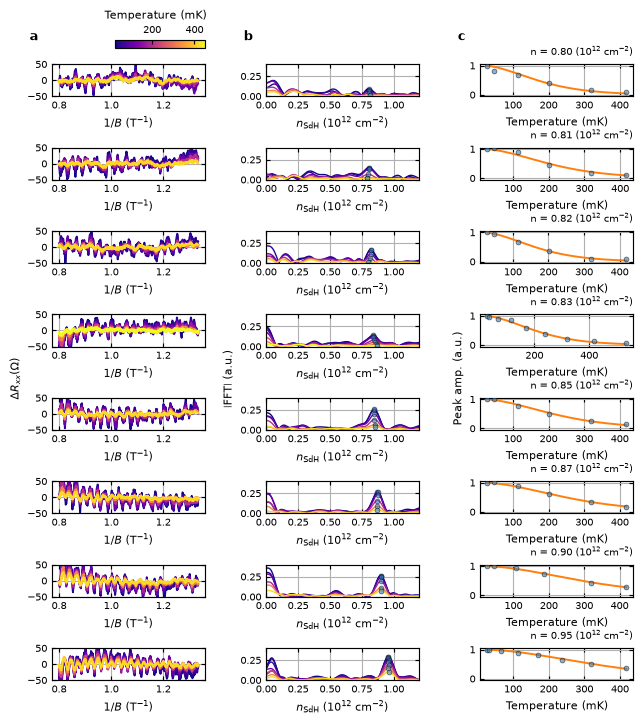

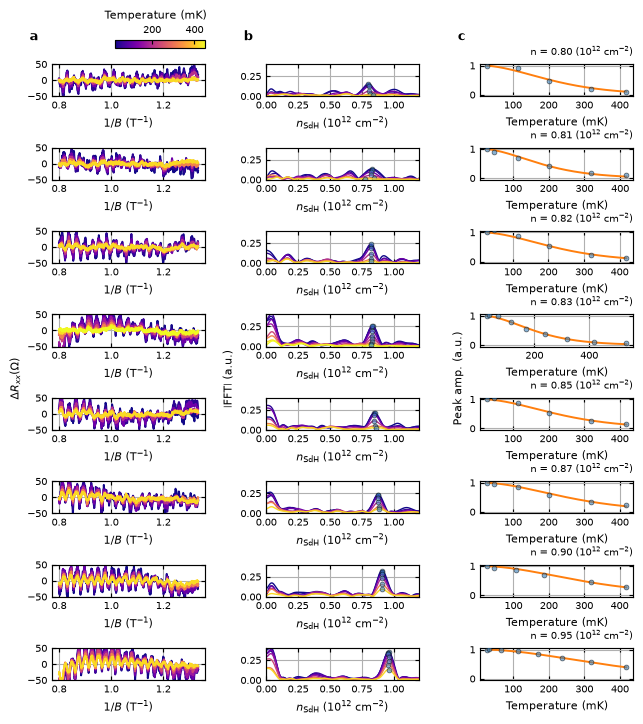

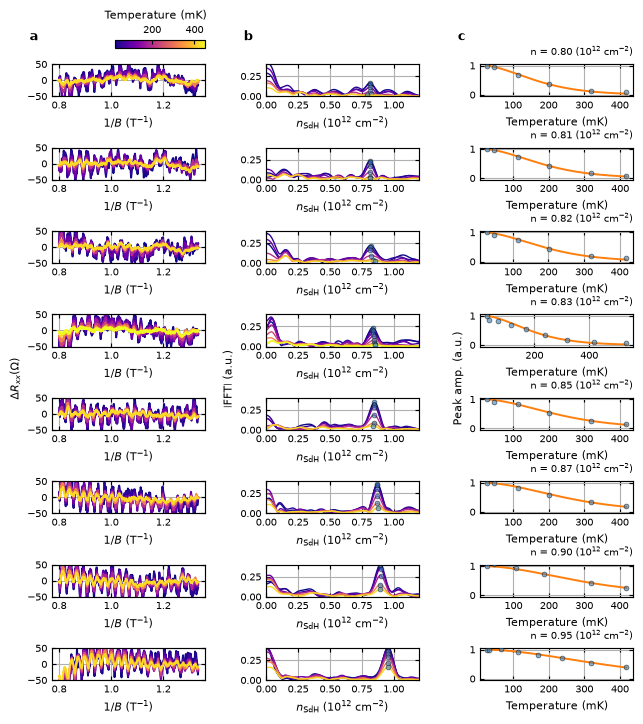

In [4]:
import scipy.optimize
label_spacer = 0.03
peak_color = '#377EB8'
def do_mass_fit(fig, axes, files, n_nom, D_nom, target_f=1, bg_subtract=None, plot_cbar=False, plot_xlabels=True, plot_ylabels=False, contact_pair =2 ):
    Vtg, Vbg = calculate_gate_voltages(n_nom, D_nom, dtg=rmg19['experimental']['dtg'], dbg=rmg19['experimental']['dbg'])
    n, D = calculate_n_D(Vtg, Vbg, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])

    popts, pcovs = [], []
    ffts = []
    freqs = []
    temps = []
    temp_cmap = plt.cm.plasma 
    temp_norm = plt.Normalize(vmin=25, vmax=450)
    sdh_peaks = []
    cb_width = 0.12
    # y_offset = 1.5
    y_offset = 1.6
    ax = axes[0]
    for file in files:
        # load in the new data
        data = sl.pload(file_path, file)
        mc_0 = data['measurement_config']
        md = sl.load_meta(file_path, file)
        xs = data['xs']
        I = data['sr830_4_X']
        Vxx = data[f'sr830_{contact_pair}_X']
        zs = Vxx/I

        
        invB_range = np.max(1/xs) - np.min(1/xs)
        num_invB_pts = int(np.ceil(invB_range / np.min(np.abs(np.diff(1/xs)))))
        temp = np.nanmean(data['T']) * 1e3

        # Get the fft
        padding = 8
        if bg_subtract == 'linear':
            zs_detrended, bg = detrend_poly(xs, zs, degree=1)
        elif bg_subtract == 'butter':
            zs_detrended, bg = detrend_butterworth(xs, zs, cutoff=1, order=4)
        elif bg_subtract == None:
            zs_detrended = zs - np.mean(zs)
        else:
            raise ValueError("Invalid Background Subtraction Scheme")
        
        interp_invB, interp_zs = interp_rxx(xs, zs_detrended, nx=num_invB_pts)
        # rxx, bg = detrend_butterworth(interp_invB, interp_zs, cutoff = 2, order=4)
        # rxx, bg = detrend_butterworth(interp_invB, interp_zs, cutoff = 3, order=3)
        # rxx = interp_zs - np.mean(interp_zs)
        rxx = interp_zs 
        
        fft, freq_b = make_vec_fft(interp_invB, rxx, n=n, padding=padding, return_complex=True, normalize=False)
        ffts.append(fft[:len(freq_b)//2] / len(freq_b) ) 
        freqs.append(freq_b[:len(freq_b)//2])
        temps.append(temp)
        
        
        plot = ax.plot(interp_invB, interp_zs, color = temp_cmap(temp_norm(temp)))
        # plot = ax.plot(interp_invB, bg, color = temp_cmap_general(temp_norm_general(temp)), alpha = 0.5)
        if plot_ylabels:
            ax.set_ylabel(r"$\Delta R_{xx} (\Omega)$", y=y_offset)
        if plot_xlabels:
            ax.set_xlabel(r"$1/B$ (T$^{-1}$)")
        ax.set_ylim(-50, 50)
        # # FOR TESTING: can use stdev and should get similar results as signal is mostly one freq.

    # if plot_cbar:
    #     sm = plt.cm.ScalarMappable(cmap=temp_cmap, norm=temp_norm)
    #     sm.set_array([])
    #     pos = ax.get_position()
    #     cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
    #     cb = plt.colorbar(sm, ax=ax, cax=cax, orientation='horizontal', shrink=0.3, pad=0.01, aspect=5)
    if plot_cbar:
        sm = plt.cm.ScalarMappable(cmap=temp_cmap, norm=temp_norm)
        sm.set_array([])
        pos = ax.get_position()
        cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.02, cb_width, 0.01])
        cb = plt.colorbar(sm, ax=ax, cax=cax, label='Temperature (mK)', orientation='horizontal', shrink=0.3, pad=0.01, aspect=5)
        cb.ax.set_xlabel('Temperature (mK)',labelpad=5, x=0.45)
        cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
        cb.ax.xaxis.set_label_position('top')    

    # plot3 - fft with temperature colormap
    ax = axes[1]
    temps = np.array(temps)     
    # Plot each curve with color based on temperature
    # epsilon = 0.2 if target_f >= 1 else 0.08
    epsilon = 0.05
    for i, (fft, freq_b, temp) in enumerate(zip(ffts, freqs, temps)):
        # fft = fft/np.amax(ffts[0])
        color = temp_cmap(temp_norm(temp))
        plot = ax.plot(freq_b*n, np.abs(fft), linewidth=1, color=color, label=f'{temp:.2f} K')
        
        peak_mask = (target_f - epsilon < freq_b) & (freq_b < target_f + epsilon)
        # peaks = find_peaks(np.abs(fft[peak_mask]),
        #     threshold_abs=1,
        #     min_distance=30,
        # )
        
        top_peak = np.argmax(np.abs(fft[peak_mask]))                
        f0 = freq_b[peak_mask][top_peak]
        y0 = np.abs(fft)[peak_mask][top_peak]
        sdh_peaks.append((f0, y0))
        ax.plot(f0*n, y0, 
            # 'x', color=peak_color, markersize=3
            'o', markerfacecolor=peak_color, markeredgecolor='k', markersize=3.5, alpha=0.6, markeredgewidth=0.5,
        )
            
    # Add colorbar
 
    print(np.max(temps))
    # ax.vlines(target_f*n, 0, 6e3, color='k', linestyle='dashed', alpha = 0.7)
   
    if plot_xlabels:
        ax.set_xlabel(r'$n_{\mathrm{SdH}}$ ($10^{12}$ cm$^{-2}$)')
    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 0.4)
    ax.set_yscale('linear')

    if plot_ylabels:
         ax.set_ylabel(r'$\left|\mathrm{FFT}\right|$ (a.u.)', y=y_offset)

    ax3 = axes[2]
    sdh_peaks = np.array(sdh_peaks)
    ax3.plot(temps, sdh_peaks[:,1]/sdh_peaks[0,1], 
        # 'x', markersize=3,
        'o', markerfacecolor=peak_color, markeredgecolor='k', markersize=3.5, alpha=0.6, markeredgewidth=0.5,
        label='Normalized SDH peak',
        zorder=999
    )
    
    if plot_ylabels:
        ax3.set_ylabel('Peak amp. (a.u.)', y=y_offset)

    B_eff = Beff(xs[0], xs[-1])
    def fit_func(T, mstar):
        return (SdH_amplitude(T, mstar, B_eff) /
                SdH_amplitude(temps[0]/1e3, mstar, B_eff))

    popt, pcov = scipy.optimize.curve_fit(
        fit_func, 
        temps/1e3, 
        sdh_peaks[:,1]/sdh_peaks[0,1], 
        p0=[1],
        bounds = (0, 10)
    )
    popts.append(popt)
    pcovs.append(pcov)

    mstar_fit = popt[0]
    mstar_err = np.sqrt(np.diag(pcov))[0]
    T_fit = np.linspace(temps.min()/1e3, temps.max()/1e3, 300) # Temp in K
    A_fit = fit_func(T_fit, *popt)
    ax3.plot(T_fit*1e3, A_fit, label=f'Fit: m* = {mstar_fit:.3f} ± {mstar_err:.3f}')
    if plot_xlabels:
        ax3.set_xlabel('Temperature (mK)')
    ax3.set_ylim(-0.05, 1.05)
    for ax in axes:
        ax.grid(True)
    nstr  = r"$10^{12}$ cm$^{-2}$"
    axes[2].set_title(
        f'n = {n:.2f} ({nstr})',
        y=1.00,
        # bbox=dict(
        #     boxstyle="round,pad=0.25",
        #     facecolor="lightblue",
        #     edgecolor="navy",
        #     linewidth=1,
        #     alpha=0.9,
        # )    
        loc='right',
        fontsize=7,
    )
    return popts, pcovs, n

n_filemap = {
    1.00: np.arange(1650, 1658), 
    0.95: np.arange(1684, 1690),
    0.925: np.arange(1714, 1720),
    0.90: np.arange(1690, 1696),
    0.88: np.arange(1661, 1670),
    0.87: np.arange(1720, 1726),
    0.86: np.arange(1726, 1732),
    0.85: np.arange(1696, 1702),
    # 0.84: np.arange(1732, 1738),
    # 0.825: np.arange(1702, 1708),
    # 0.80: np.arange(1708, 1714),
}
n_filemap = dict(reversed(n_filemap.items()))

for contact_pair in [1,2,3]:
    fig = plt.figure(figsize=(7.5, 8))
    n_files = len(n_filemap)
    gs = GridSpec(n_files, 3, wspace=0.4, hspace=1.6, 
        # height_ratios=[1,1,1,1,0.67, 0.67]
    )

    # fig, axes = plt.subplots(1, 3, figsize=(9*1.618, 3))
    all_axes = [ 
        [fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(n_files)
    ]


    all_mstars = np.zeros(len(n_filemap))
    stdevs = np.zeros(len(n_filemap))
    ns_calc = np.zeros(len(n_filemap))
    # contact_pair = 3

    for i, (n, files) in enumerate(n_filemap.items()):
        masses, pcovs, n_calc = do_mass_fit(fig, all_axes[i], n_filemap[n], n_nom = n, D_nom = 1, target_f = 1, bg_subtract= 'butter', 
            plot_cbar=i==0, 
            # plot_xlabels=i==n_files-1,
            plot_ylabels = i == 4,
            plot_xlabels = True,
            contact_pair = contact_pair,
        )
        all_mstars[i] = np.ravel(masses).item()   # NumPy>=2: no implicit (1,)->scalar
        stdevs[i] = np.ravel(np.sqrt(pcovs)).item()
        ns_calc[i] = n_calc


    for i, ax in enumerate(all_axes[0]):
        pos = ax.get_position()
        fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, chr(97+i), fontweight='bold')


    plt.savefig(f'figS_mstar_qm_big_{contact_names[contact_pair]}.pdf', dpi=600, bbox_inches='tight',
                pad_inches=0.06, transparent=False)






    df = pd.DataFrame({
        'n': ns_calc,
        'mstar': all_mstars,
        'mstar_stdev': stdevs,
    })
    df.to_csv(f'figS_mstar_qm_{contact_names[contact_pair]}_big.csv', index=False)